In [33]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "DataSet" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import datetime as dt
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
from collections import Counter, defaultdict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from scipy import stats as sps
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, _tree, plot_tree
from xgboost import XGBClassifier, XGBRegressor


In [99]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

PCA 保留 131 個主成分


In [100]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


---
---

依照KMEANS分的cluster=0/1各群做local的近似函數, 只是格子點太大, 現在在想方設法讓模型有個結果

全下

In [ ]:
# ====== 最低限度修改：降峰值記憶體拷貝 + 取消 X1 hstack ======
# local_surrogate_block_fullgrid_ols：
# - 大矩陣用 float32（Zs/Z/y/X_block），累積量用 float64
# - 不建立 X1 = [1, X_block]，改手動更新 Sxx/Sxy
# - np.repeat 改成預先配置 + 填值（少一次不必要拷貝路徑）
def _center_index(q, k):
    # all-zero offset 對應 base-(2k+1) 數字每位都是 k
    B = 2 * k + 1
    return int(k * (B**q - 1) // (B - 1)) if B != 1 else 0

def _iter_fullgrid_offsets_chunked(q, k, chunk_size, center_first=True):
    """
    以 chunk 方式產生 full grid offsets，不一次存滿 (2k+1)^q × q。
    若 center_first=True，先 yield 全 0 offset，再 yield 其餘點（不重複）。
    """
    B = 2 * k + 1
    n = int(B**q)

    if center_first:
        cidx = _center_index(q, k)
        yield np.zeros((1, q), dtype=float), np.array([cidx], dtype=np.int64), n

        # 0..n-1 排除 cidx
        s = 0
        while s < n:
            e = min(n, s + chunk_size)
            idx = np.arange(s, e, dtype=np.int64)
            mask = idx != cidx
            if mask.any():
                idx2 = idx[mask]
                yield _offsets_from_linear_indices(idx2, q, k), idx2, n
            s = e
    else:
        s = 0
        while s < n:
            e = min(n, s + chunk_size)
            idx = np.arange(s, e, dtype=np.int64)
            yield _offsets_from_linear_indices(idx, q, k), idx, n
            s = e

def _offsets_from_linear_indices(idx, q, k):
    """
    idx: (m,) 線性索引
    回傳 offsets: (m, q)，每列是 [-k..k] 的 q 維整數位移（float32）
    """
    idx = idx.astype(np.int64, copy=False)
    B = 2 * k + 1
    offsets = np.empty((idx.size, q), dtype=np.float32)
    x = idx.copy()
    for d in range(q - 1, -1, -1):
        x, r = np.divmod(x, B)
        offsets[:, d] = (r.astype(np.float32) - np.float32(k))
    return offsets


def _ols_from_sufficient_stats(Sxx, Sxy, Syy, sum_y, n, q):
    """
    用累積量求 OLS 係數與統計量
    Sxx = X'X (q+1,q+1), Sxy = X'y (q+1,), Syy = y'y, sum_y = sum(y)
    """
    p_params = q + 1
    df_resid = n - p_params
    out = {}

    # beta
    try:
        beta = np.linalg.solve(Sxx, Sxy)
    except np.linalg.LinAlgError:
        beta = np.full(p_params, np.nan, dtype=np.float64)

    # SSE = y'y - 2 b'X'y + b'X'X b
    if np.all(np.isfinite(beta)):
        SSE = float(Syy - 2.0 * beta @ Sxy + beta @ (Sxx @ beta))
    else:
        SSE = np.nan

    # TSS
    ybar = float(sum_y / n) if n > 0 else np.nan
    TSS = float(Syy - n * (ybar**2)) if n > 0 else np.nan

    # sigma2
    sigma2 = float(SSE / df_resid) if (df_resid > 0 and np.isfinite(SSE)) else np.nan

    # inv(X'X)
    try:
        Sxx_inv = np.linalg.inv(Sxx)
    except np.linalg.LinAlgError:
        Sxx_inv = np.full_like(Sxx, np.nan, dtype=np.float64)

    # se, t, p
    if np.isfinite(sigma2) and np.all(np.isfinite(Sxx_inv)):
        cov = sigma2 * Sxx_inv
        se = np.sqrt(np.diag(cov))
        tval = beta / se
        if df_resid > 0:
            pval = 2.0 * sps.t.sf(np.abs(tval), df=df_resid)
        else:
            pval = np.full_like(tval, np.nan, dtype=np.float64)
    else:
        se = np.full(p_params, np.nan, dtype=np.float64)
        tval = np.full(p_params, np.nan, dtype=np.float64)
        pval = np.full(p_params, np.nan, dtype=np.float64)

    # r2
    r2 = (1.0 - SSE / TSS) if (np.isfinite(SSE) and np.isfinite(TSS) and TSS > 0) else np.nan

    # aic/bic
    kparam = p_params
    if n > 0 and np.isfinite(SSE) and SSE > 0:
        ll_term = n * np.log(SSE / n)
        aic = float(ll_term + 2.0 * kparam)
        bic = float(ll_term + np.log(n) * kparam)
    else:
        aic = np.nan
        bic = np.nan

    out["beta"] = beta
    out["SSE"] = SSE
    out["r2"] = float(r2) if np.isfinite(r2) else np.nan
    out["se"] = se                   
    out["t"] = tval
    out["p"] = pval
    out["aic"] = aic
    out["bic"] = bic
    out["df_resid"] = int(df_resid)
    return out


def local_surrogate_block_fullgrid_ols(
    x0,
    blackbox_model,
    block_cols,
    delta,
    k,
    scaler=None,
    chunk_size=10000,
    store_yhat=False,
    store_yblackbox=False,
):
    x0 = np.asarray(x0, np.float32).reshape(1, -1)

    # scaler.transform 通常吐 float64；立刻壓回 float32（大矩陣都用 float32）
    if scaler is not None:
        x0_scaled = scaler.transform(x0).astype(np.float32, copy=False)
    else:
        x0_scaled = x0.copy()

    p_model = x0_scaled.shape[1]
    block_cols = np.asarray(block_cols, dtype=np.int64)
    q = int(block_cols.size)
    if q < 1:
        raise ValueError("block_cols 至少 1 維")
    if k < 0:
        raise ValueError("k must be >= 0")

    B = 2 * k + 1
    n_total = int(B**q)

    if store_yhat or store_yblackbox:
        raise ValueError("store_yhat/store_yblackbox 在大 n 下不可用（請關掉）。")

    # sufficient stats（用 float64 累積）
    Sxx = np.zeros((q + 1, q + 1), dtype=np.float64)
    Sxy = np.zeros((q + 1,), dtype=np.float64)
    Syy = 0.0
    sum_y = 0.0
    n_seen = 0

    # 預先配置 chunk 用的大矩陣（重複利用，避免每回合配置/釋放）
    Zs_chunk = np.empty((chunk_size, p_model), dtype=np.float32)

    for offsets_q, idx_linear, n_full in _iter_fullgrid_offsets_chunked(q, k, chunk_size, center_first=True):
        m = offsets_q.shape[0]
        if m == 0:
            continue

        # X_block: (m,q) 只用 float32
        X_block = (np.float32(delta) * offsets_q).astype(np.float32, copy=False)

        # 生成完整 p 維輸入（scaled 空間）
        # 原本 np.repeat 會走一條明顯的拷貝路徑；改成填值到預配置陣列
        Zs = Zs_chunk[:m]
        Zs[:] = x0_scaled  # broadcast fill
        Zs[:, block_cols] += X_block

        # 回到原始尺度再進黑箱（仍盡量保持 float32）
        if scaler is not None:
            Z_chunk = scaler.inverse_transform(Zs).astype(np.float32, copy=False)
        else:
            Z_chunk = Zs

        if hasattr(blackbox_model, "predict_proba"):
            y = blackbox_model.predict_proba(Z_chunk)[:, 1]
        else:
            y = blackbox_model.predict(Z_chunk)

        y = np.asarray(y, dtype=np.float32).reshape(-1)
        if y.size != m:
            raise ValueError("blackbox 輸出長度與 chunk 不一致")

        # ====== 不建立 X1=[1, X_block]，改手動更新（等價但少一次 hstack） ======
        # Sxx = [[m,      1'X],
        #        [X'1,    X'X]]
        Sxx[0, 0] += m
        sx = X_block.sum(axis=0, dtype=np.float64)          # (q,)
        Sxx[0, 1:] += sx
        Sxx[1:, 0] += sx
        Sxx[1:, 1:] += (X_block.T @ X_block).astype(np.float64, copy=False)

        # Sxy = [1'y, X'y]
        sy = float(y.sum(dtype=np.float64))
        Sxy[0] += sy
        Sxy[1:] += (X_block.T @ y).astype(np.float64, copy=False)

        # Syy, sum_y
        Syy += float(y @ y)
        sum_y += sy
        n_seen += int(m)

    if n_seen != n_total:
        raise RuntimeError(f"n_seen({n_seen}) != n_total({n_total})")

    st = _ols_from_sufficient_stats(Sxx, Sxy, Syy, sum_y, n_seen, q)

    info = {
        "n": int(n_seen),
        "q": int(q),
        "k": int(k),
        "delta": float(delta),
        "block_cols": block_cols.tolist(),
        "coef_block": st["beta"][1:].copy(),
        "intercept": float(st["beta"][0]),
        "se_block": st["se"][1:].copy(),              
        "t_block": st["t"][1:].copy(),
        "p_block": st["p"][1:].copy(),
        "intercept_p": float(st["p"][0]) if np.isfinite(st["p"][0]) else np.nan,
        "r2": float(st["r2"]),
        "aic": float(st["aic"]),
        "bic": float(st["bic"]),
        "df_resid": int(st["df_resid"]),
    }
    return info


def run_blockwise_fullgrid_pvalues(
    x0,
    blackbox_model,
    feature_names,
    block_size,
    k,
    delta=0.1,
    scaler=None,
    chunk_size=10000,
):
    p = len(feature_names)
    rows = []

    n_blocks = int(np.ceil(p / block_size))
    for bi in range(n_blocks):
        j0 = bi * block_size
        j1 = min(p, (bi + 1) * block_size)
        block_cols = list(range(j0, j1))

        info = local_surrogate_block_fullgrid_ols(
            x0=x0,
            blackbox_model=blackbox_model,
            block_cols=block_cols,
            delta=delta,
            k=k,
            scaler=scaler,
            chunk_size=chunk_size,
            store_yhat=False,
            store_yblackbox=False,
        )

        for t, col in enumerate(block_cols):
            coef = float(info["coef_block"][t])
            rows.append({
                "feature": feature_names[col],
                "block_id": int(bi),
                "coef": coef,
                "abs_coef": abs(coef),                
                "t": float(info["t_block"][t]),
                "p": float(info["p_block"][t]),
                "r2_block": info["r2"],
                "df_resid": info["df_resid"],
            })

    df = pd.DataFrame(rows)
    df = df.sort_values(["p", "abs_coef"], ascending=[True, False]).reset_index(drop=True)
    df["rank_p"] = np.arange(1, len(df) + 1)
    return df

In [ ]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42):
    y_all = np.asarray(y_all).astype(int)
    p_oof = np.full(len(y_all), np.nan, dtype=float)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            # 只對 training 做 SMOTE（不把合成樣本寫入 p_oof）
            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)
            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

def fit_blackbox_per_cluster(X_all_df, y_all, c_all):
    models = {}
    y_all = np.asarray(y_all)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=42,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
        models[c] = m.fit(Xc, yc)

    return models

# 1) 先算每群 OOF 機率（用來挑 x0）
p_hat_oof = oof_proba_per_cluster(X_all_df, y_real, c_all)

# 2) 最後用全資料重訓每群最終黑箱（用於 lattice 探測與 surrogate 擬合）
blackbox_by_c = fit_blackbox_per_cluster(X_all_df, y_real, c_all)


# ========= x0 挑選（在各群內、用該群 blackbox 的 p_hat） =========
def pick_x0_indices(p, target, topk=10, min_p=None):
    p = np.asarray(p).reshape(-1)
    idx = np.arange(len(p))
    if min_p is not None:
        idx = idx[p[idx] >= min_p]
    if idx.size == 0:
        return idx
    order = np.argsort(np.abs(p[idx] - target))
    return idx[order[:min(topk, idx.size)]]
# 只改「呼叫端參數」到能撐住 k=3 的設定：
# 核心：block_size 必須改 10；k 改 3；chunk_size 保留 10000
# 其餘流程不動（最低限度修改）

def run_block_pvalues_per_cluster_center(
    X_all_df, c_all, blackbox_by_c, p_hat_oof,
    topk=5, target=0.5,
    block_size=10, k=3, delta=0.1,
    chunk_size=500_000,                 # ← 新增/改成 500000
    random_state=42,
):
    out = []
    feature_names = list(X_all_df.columns)

    for c in sorted(blackbox_by_c.keys()):
        idx_c = np.where(c_all == c)[0]
        m = blackbox_by_c[c]
        p_hat_c = np.asarray(p_hat_oof)[idx_c]

        loc = pick_x0_indices(p_hat_c, target=target, topk=topk)
        if len(loc) == 0:
            continue

        global_ids = [int(idx_c[pos]) for pos in loc]
        x_center = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

        df_p = run_blockwise_fullgrid_pvalues(
            x0=x_center,
            blackbox_model=m,
            feature_names=feature_names,
            block_size=block_size,
            k=k,
            delta=delta,
            scaler=None,
            chunk_size=chunk_size,         # ← 改成 500000
        )

        df_p["cluster"] = int(c)
        df_p["x0_indices"] = [global_ids] * len(df_p)
        df_p["p_oof_center"] = float(p_hat_c[loc].mean())
        df_p["p_final_center"] = float(m.predict_proba(x_center.reshape(1, -1))[:, 1][0])

        out.append(df_p)

    return pd.concat(out, ignore_index=True) if len(out) else pd.DataFrame()


df_all_p = run_block_pvalues_per_cluster_center(
    X_all_df=X_all_df,
    c_all=c_all,
    blackbox_by_c=blackbox_by_c,
    p_hat_oof=p_hat_oof,
    topk=10,
    target=0.5,
    block_size=10,
    k=3,
    delta=0.1,
    chunk_size=500_000,                 # ← 改成 500000
)
df_all_p.head(50)


---
---

抽樣

In [ ]:
# ====== A1 最低限度修改：每個 block 固定抽 n_use 個格子點做 OLS（不跑 full grid）======
# 改動點：
# 1) 新增 _iter_sampled_offsets_chunked：在 [0, (2k+1)^q) 的線性索引中「不放回抽樣」
#    - center_first=True：永遠先丟中心點（offset=0）
# 2) local_surrogate_block_fullgrid_ols 新增 n_use、seed
#    - 迴圈改用 _iter_sampled_offsets_chunked
#    - 移除 n_seen==n_total 的檢查（因為不再跑滿全格點）
# 3) run_blockwise_fullgrid_pvalues 新增 n_use、seed，往下傳

def _center_index(q, k):
    B = 2 * k + 1
    return int(k * (B**q - 1) // (B - 1)) if B != 1 else 0

def _offsets_from_linear_indices(idx, q, k):
    idx = idx.astype(np.int64, copy=False)
    B = 2 * k + 1
    offsets = np.empty((idx.size, q), dtype=np.float32)
    x = idx.copy()
    for d in range(q - 1, -1, -1):
        x, r = np.divmod(x, B)
        offsets[:, d] = (r.astype(np.float32) - np.float32(k))
    return offsets

def _iter_sampled_offsets_chunked(q, k, n_use, chunk_size, seed=0, center_first=True):
    """
    A1：只抽 n_use 個格子點（不跑滿 (2k+1)^q）。
    - 不放回抽樣線性索引
    - center_first=True：先 yield 中心點（全 0 offset），再 yield 其餘抽樣點
    """
    B = 2 * k + 1
    n_total = int(B**q)
    if n_use <= 0:
        raise ValueError("n_use must be >= 1")
    n_use = int(min(n_use, n_total))

    cidx = _center_index(q, k)
    rng = np.random.default_rng(seed)

    # 抽樣其餘索引（排除中心點）
    if n_use == 1:
        sampled = np.empty((0,), dtype=np.int64)
    else:
        # 在 [0, n_total-1) 抽 (n_use-1) 個，再映射跳過 cidx
        # 這樣避免建立 0..n_total-1 的大陣列
        u = rng.choice(n_total - 1, size=n_use - 1, replace=False).astype(np.int64, copy=False)
        sampled = u + (u >= cidx)  # >=cidx 的往後挪一格，等效於從全集排除 cidx

    # 可選：為了可重現且利於 cache，排序後輸出
    sampled.sort()

    if center_first:
        yield np.zeros((1, q), dtype=np.float32), np.array([cidx], dtype=np.int64), n_total, n_use

    # 分 chunk yield
    s = 0
    while s < sampled.size:
        e = min(sampled.size, s + chunk_size)
        idx = sampled[s:e]
        yield _offsets_from_linear_indices(idx, q, k), idx, n_total, n_use
        s = e


def _ols_from_sufficient_stats(Sxx, Sxy, Syy, sum_y, n, q):
    """
    用累積量求 OLS 係數與統計量
    Sxx = X'X (q+1,q+1), Sxy = X'y (q+1,), Syy = y'y, sum_y = sum(y)
    """
    p_params = q + 1
    df_resid = n - p_params
    out = {}

    # beta
    try:
        beta = np.linalg.solve(Sxx, Sxy)
    except np.linalg.LinAlgError:
        beta = np.full(p_params, np.nan, dtype=np.float64)

    # SSE = y'y - 2 b'X'y + b'X'X b
    if np.all(np.isfinite(beta)):
        SSE = float(Syy - 2.0 * beta @ Sxy + beta @ (Sxx @ beta))
    else:
        SSE = np.nan

    # TSS
    ybar = float(sum_y / n) if n > 0 else np.nan
    TSS = float(Syy - n * (ybar**2)) if n > 0 else np.nan

    # sigma2
    sigma2 = float(SSE / df_resid) if (df_resid > 0 and np.isfinite(SSE)) else np.nan

    # inv(X'X)
    try:
        Sxx_inv = np.linalg.inv(Sxx)
    except np.linalg.LinAlgError:
        Sxx_inv = np.full_like(Sxx, np.nan, dtype=np.float64)

    # se, t, p
    if np.isfinite(sigma2) and np.all(np.isfinite(Sxx_inv)):
        cov = sigma2 * Sxx_inv
        se = np.sqrt(np.diag(cov))
        tval = beta / se
        if df_resid > 0:
            pval = 2.0 * sps.t.sf(np.abs(tval), df=df_resid)
        else:
            pval = np.full_like(tval, np.nan, dtype=np.float64)
    else:
        se = np.full(p_params, np.nan, dtype=np.float64)
        tval = np.full(p_params, np.nan, dtype=np.float64)
        pval = np.full(p_params, np.nan, dtype=np.float64)

    # r2
    r2 = (1.0 - SSE / TSS) if (np.isfinite(SSE) and np.isfinite(TSS) and TSS > 0) else np.nan

    # aic/bic
    kparam = p_params
    if n > 0 and np.isfinite(SSE) and SSE > 0:
        ll_term = n * np.log(SSE / n)
        aic = float(ll_term + 2.0 * kparam)
        bic = float(ll_term + np.log(n) * kparam)
    else:
        aic = np.nan
        bic = np.nan

    out["beta"] = beta
    out["SSE"] = SSE
    out["r2"] = float(r2) if np.isfinite(r2) else np.nan
    out["se"] = se                   
    out["t"] = tval
    out["p"] = pval
    out["aic"] = aic
    out["bic"] = bic
    out["df_resid"] = int(df_resid)
    return out

def local_surrogate_block_fullgrid_ols(
    x0,
    blackbox_model,
    block_cols,
    delta,
    k,
    scaler=None,
    chunk_size=500_000,   # <<< 改：預設 50 萬
    n_use=100_000,
    seed=0,
    store_yhat=False,
    store_yblackbox=False,
):
    x0 = np.asarray(x0, np.float32).reshape(1, -1)

    if scaler is not None:
        x0_scaled = scaler.transform(x0).astype(np.float32, copy=False)
    else:
        x0_scaled = x0.copy()

    p_model = x0_scaled.shape[1]
    block_cols = np.asarray(block_cols, dtype=np.int64)
    q = int(block_cols.size)
    if q < 1:
        raise ValueError("block_cols 至少 1 維")
    if k < 0:
        raise ValueError("k must be >= 0")

    if store_yhat or store_yblackbox:
        raise ValueError("store_yhat/store_yblackbox 在大 n 下不可用（請關掉）。")

    # >>> 最低限度關鍵改動：chunk_size 直接夾到 n_use（抽 10 萬就一次跑完，不需要 chunking）
    chunk_size = int(min(chunk_size, n_use))

    # sufficient stats（float64）
    Sxx = np.zeros((q + 1, q + 1), dtype=np.float64)
    Sxy = np.zeros((q + 1,), dtype=np.float64)
    Syy = 0.0
    sum_y = 0.0
    n_seen = 0

    # 預配置
    Zs_chunk = np.empty((chunk_size, p_model), dtype=np.float32)

    for offsets_q, idx_linear, n_total, n_use_eff in _iter_sampled_offsets_chunked(
        q=q, k=k, n_use=n_use, chunk_size=chunk_size, seed=seed, center_first=True
    ):
        m = offsets_q.shape[0]
        if m == 0:
            continue

        X_block = (np.float32(delta) * offsets_q).astype(np.float32, copy=False)

        Zs = Zs_chunk[:m]
        Zs[:] = x0_scaled
        Zs[:, block_cols] += X_block

        if scaler is not None:
            Z_chunk = scaler.inverse_transform(Zs).astype(np.float32, copy=False)
        else:
            Z_chunk = Zs

        if hasattr(blackbox_model, "predict_proba"):
            y = blackbox_model.predict_proba(Z_chunk)[:, 1]
        else:
            y = blackbox_model.predict(Z_chunk)

        y = np.asarray(y, dtype=np.float32).reshape(-1)
        if y.size != m:
            raise ValueError("blackbox 輸出長度與 chunk 不一致")

        Sxx[0, 0] += m
        sx = X_block.sum(axis=0, dtype=np.float64)
        Sxx[0, 1:] += sx
        Sxx[1:, 0] += sx
        Sxx[1:, 1:] += (X_block.T @ X_block).astype(np.float64, copy=False)

        sy = float(y.sum(dtype=np.float64))
        Sxy[0] += sy
        Sxy[1:] += (X_block.T @ y).astype(np.float64, copy=False)

        Syy += float(y @ y)
        sum_y += sy
        n_seen += int(m)

    if n_seen <= (q + 1):
        raise RuntimeError(f"n_seen({n_seen}) <= q+1({q+1})，df_resid 不足，請調大 n_use")

    st = _ols_from_sufficient_stats(Sxx, Sxy, Syy, sum_y, n_seen, q)

    info = {
        "n_total_grid": int((2 * k + 1) ** q),
        "n_used": int(n_seen),
        "q": int(q),
        "k": int(k),
        "delta": float(delta),
        "seed": int(seed),
        "block_cols": block_cols.tolist(),
        "coef_block": st["beta"][1:].copy(),
        "intercept": float(st["beta"][0]),
        "se_block": st["se"][1:].copy(),
        "t_block": st["t"][1:].copy(),
        "p_block": st["p"][1:].copy(),
        "intercept_p": float(st["p"][0]) if np.isfinite(st["p"][0]) else np.nan,
        "r2": float(st["r2"]),
        "aic": float(st["aic"]),
        "bic": float(st["bic"]),
        "df_resid": int(st["df_resid"]),
    }
    return info

def run_blockwise_fullgrid_pvalues(
    x0,
    blackbox_model,
    feature_names,
    block_size,
    k,
    delta=0.1,
    scaler=None,
    chunk_size=500_000,   # <<< 改：預設 50 萬
    n_use=100_000,
    seed=0,
):
    p = len(feature_names)
    rows = []

    n_blocks = int(np.ceil(p / block_size))
    for bi in range(n_blocks):
        j0 = bi * block_size
        j1 = min(p, (bi + 1) * block_size)
        block_cols = list(range(j0, j1))

        info = local_surrogate_block_fullgrid_ols(
            x0=x0,
            blackbox_model=blackbox_model,
            block_cols=block_cols,
            delta=delta,
            k=k,
            scaler=scaler,
            chunk_size=chunk_size,
            n_use=n_use,
            seed=seed + bi,
            store_yhat=False,
            store_yblackbox=False,
        )

        for t, col in enumerate(block_cols):
            coef = float(info["coef_block"][t])
            rows.append({
                "feature": feature_names[col],
                "block_id": int(bi),
                "coef": coef,
                "abs_coef": abs(coef),
                "t": float(info["t_block"][t]),
                "p": float(info["p_block"][t]),
                "r2_block": info["r2"],
                "df_resid": info["df_resid"],
                "n_used": info["n_used"],
                "n_total_grid": info["n_total_grid"],
            })

    df = pd.DataFrame(rows)
    df = df.sort_values(["p", "abs_coef"], ascending=[True, False]).reset_index(drop=True)
    df["rank_p"] = np.arange(1, len(df) + 1)
    return df



In [ ]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42):
    y_all = np.asarray(y_all).astype(int)
    p_oof = np.full(len(y_all), np.nan, dtype=float)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            # 只對 training 做 SMOTE（不把合成樣本寫入 p_oof）
            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)
            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

def fit_blackbox_per_cluster(X_all_df, y_all, c_all):
    models = {}
    y_all = np.asarray(y_all)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=42,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
        models[c] = m.fit(Xc, yc)

    return models

# 1) 先算每群 OOF 機率（用來挑 x0）
p_hat_oof = oof_proba_per_cluster(X_all_df, y_real, c_all)

# 2) 最後用全資料重訓每群最終黑箱（用於 lattice 探測與 surrogate 擬合）
blackbox_by_c = fit_blackbox_per_cluster(X_all_df, y_real, c_all)


# ========= x0 挑選（在各群內、用該群 blackbox 的 p_hat） =========
def pick_x0_indices(p, target, topk=10, min_p=None):
    p = np.asarray(p).reshape(-1)
    idx = np.arange(len(p))
    if min_p is not None:
        idx = idx[p[idx] >= min_p]
    if idx.size == 0:
        return idx
    order = np.argsort(np.abs(p[idx] - target))
    return idx[order[:min(topk, idx.size)]]

# ===== 只做「chunk_size 夾到 n_use」與「預設 50 萬」一致化的最低限度修改 =====
# 改動點：
# 1) run_block_pvalues_per_cluster_center：chunk_size 預設改 500_000（對齊你硬體可跑 50 萬點）
# 2) run_block_pvalues_per_cluster_center：呼叫 run_blockwise_fullgrid_pvalues 前，把 chunk_size=min(chunk_size, n_use)
#    -> n_use=100_000 時等同一次跑完；n_use=500_000 時才會一次跑 50 萬

def run_block_pvalues_per_cluster_center(
    X_all_df, c_all, blackbox_by_c, p_hat_oof,
    topk=5, target=0.5,
    block_size=10, k=3, delta=0.1,
    chunk_size=500_000,         # ← 改：預設 50 萬
    n_use=100_000,              # ← 總抽樣點數
    seed=42,
    random_state=42,
):
    out = []
    feature_names = list(X_all_df.columns)

    # >>> 最低限度：抽 10 萬就不需要 chunking，直接一次跑完
    chunk_size = int(min(chunk_size, n_use))

    for c in sorted(blackbox_by_c.keys()):
        idx_c = np.where(c_all == c)[0]
        m = blackbox_by_c[c]
        p_hat_c = np.asarray(p_hat_oof)[idx_c]

        loc = pick_x0_indices(p_hat_c, target=target, topk=topk)
        if len(loc) == 0:
            continue

        global_ids = [int(idx_c[pos]) for pos in loc]
        x_center = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

        df_p = run_blockwise_fullgrid_pvalues(
            x0=x_center,
            blackbox_model=m,
            feature_names=feature_names,
            block_size=block_size,
            k=k,
            delta=delta,
            scaler=None,
            chunk_size=chunk_size,   # ← 會自動是 min(500000, n_use)
            n_use=n_use,
            seed=seed + 1000*c,
        )

        df_p["cluster"] = int(c)
        df_p["x0_indices"] = [global_ids] * len(df_p)
        df_p["p_oof_center"] = float(p_hat_c[loc].mean())
        df_p["p_final_center"] = float(m.predict_proba(x_center.reshape(1, -1))[:, 1][0])

        out.append(df_p)

    return pd.concat(out, ignore_index=True) if len(out) else pd.DataFrame()


# 呼叫端：把 chunk_size 改成 500_000（或不寫就吃預設）
df_all_p = run_block_pvalues_per_cluster_center(
    X_all_df=X_all_df,
    c_all=c_all,
    blackbox_by_c=blackbox_by_c,
    p_hat_oof=p_hat_oof,
    topk=10,
    target=0.5,
    block_size=20,
    k=3,
    delta=0.1,
    chunk_size=500_000,  # ← 改：對齊 50 萬
    n_use=100_000,
    seed=42,
)

df_all_p.head(50)


---
---

In [17]:
# ====== 最低限度修改：p=30、3 輪(0.01, 0.005, 0.001)、每輪補齊到 30、每次樣本 block 都不同 ======
# - active_cols：目前要跑的特徵索引集合（會被篩選後變動）
# - 每輪依 threshold 篩選後，重新分組，每組最多 30
# - 不足 30 就從「被篩掉的」裡補回來湊滿 30（不改 active，只是為了 fit 時滿 30）
# - 每個 block 的格子點都不一樣：seed 用 (base_seed + round*100000 + block_id)

def _sample_offsets_block(q, k, n_block, center_first=True, rng=None):
    """
    回傳 offsets: (n_block, q) ，元素為 [-k..k] 的整數位移（float32）
    center_first=True：第一筆固定為全 0
    """
    if rng is None:
        rng = np.random.default_rng(0)

    offsets = rng.integers(-k, k + 1, size=(n_block, q), dtype=np.int16).astype(np.float32)
    if center_first and n_block > 0:
        offsets[0, :] = 0.0
    return offsets


def _ols_from_sufficient_stats(Sxx, Sxy, Syy, sum_y, n, q):
    """
    用累積量求 OLS 係數與統計量
    Sxx = X'X (q+1,q+1), Sxy = X'y (q+1,), Syy = y'y, sum_y = sum(y)
    """
    p_params = q + 1
    df_resid = n - p_params
    out = {}

    try:
        beta = np.linalg.solve(Sxx, Sxy)
    except np.linalg.LinAlgError:
        beta = np.full(p_params, np.nan, dtype=np.float64)

    if np.all(np.isfinite(beta)):
        SSE = float(Syy - 2.0 * beta @ Sxy + beta @ (Sxx @ beta))
    else:
        SSE = np.nan

    ybar = float(sum_y / n) if n > 0 else np.nan
    TSS = float(Syy - n * (ybar**2)) if n > 0 else np.nan

    sigma2 = float(SSE / df_resid) if (df_resid > 0 and np.isfinite(SSE)) else np.nan

    try:
        Sxx_inv = np.linalg.inv(Sxx)
    except np.linalg.LinAlgError:
        Sxx_inv = np.full_like(Sxx, np.nan, dtype=np.float64)

    if np.isfinite(sigma2) and np.all(np.isfinite(Sxx_inv)):
        cov = sigma2 * Sxx_inv
        se = np.sqrt(np.diag(cov))
        tval = beta / se
        if df_resid > 0:
            pval = 2.0 * sps.t.sf(np.abs(tval), df=df_resid)
        else:
            pval = np.full_like(tval, np.nan, dtype=np.float64)
    else:
        se = np.full(p_params, np.nan, dtype=np.float64)
        tval = np.full(p_params, np.nan, dtype=np.float64)
        pval = np.full(p_params, np.nan, dtype=np.float64)

    r2 = (1.0 - SSE / TSS) if (np.isfinite(SSE) and np.isfinite(TSS) and TSS > 0) else np.nan

    kparam = p_params
    if n > 0 and np.isfinite(SSE) and SSE > 0:
        ll_term = n * np.log(SSE / n)
        aic = float(ll_term + 2.0 * kparam)
        bic = float(ll_term + np.log(n) * kparam)
    else:
        aic = np.nan
        bic = np.nan

    out["beta"] = beta
    out["SSE"] = SSE
    out["r2"] = float(r2) if np.isfinite(r2) else np.nan
    out["se"] = se
    out["t"] = tval
    out["p"] = pval
    out["aic"] = aic
    out["bic"] = bic
    out["df_resid"] = int(df_resid)
    return out


def local_surrogate_block_sample_ols(
    x0,
    blackbox_model,
    block_cols,
    delta,
    k,
    scaler=None,
    n_block=500_000,
    rng_seed=0,
    store_yhat=False,
    store_yblackbox=False,
):
    """
    一個樣本 block 只 fit 一組特徵
    - 生成 n_block 個 offsets（抽樣近似）
    - 黑箱只跑這 n_block 點
    - 只用 block_cols 的 q 維特徵做 OLS，輸出 p-value
    """
    x0 = np.asarray(x0, np.float32).reshape(1, -1)

    if scaler is not None:
        x0_scaled = scaler.transform(x0).astype(np.float32, copy=False)
    else:
        x0_scaled = x0.copy()

    p_model = x0_scaled.shape[1]
    block_cols = np.asarray(block_cols, dtype=np.int64)
    q = int(block_cols.size)
    if q < 1:
        raise ValueError("block_cols 至少 1 維")
    if k < 0:
        raise ValueError("k must be >= 0")
    if store_yhat or store_yblackbox:
        raise ValueError("store_yhat/store_yblackbox 在大 n 下不可用（請關掉）。")

    rng = np.random.default_rng(rng_seed)

    # 生成 (n_block, q) offsets -> X_block (n_block, q)
    offsets_q = _sample_offsets_block(q, k, n_block, center_first=True, rng=rng)
    X_block = (np.float32(delta) * offsets_q).astype(np.float32, copy=False)

    # 生成完整 p 維輸入（scaled 空間）
    Zs = np.empty((n_block, p_model), dtype=np.float32)
    Zs[:] = x0_scaled
    Zs[:, block_cols] += X_block

    # 回到原始尺度再進黑箱
    if scaler is not None:
        Z = scaler.inverse_transform(Zs).astype(np.float32, copy=False)
    else:
        Z = Zs

    if hasattr(blackbox_model, "predict_proba"):
        y = blackbox_model.predict_proba(Z)[:, 1]
    else:
        y = blackbox_model.predict(Z)

    y = np.asarray(y, dtype=np.float32).reshape(-1)
    if y.size != n_block:
        raise ValueError("blackbox 輸出長度與 n_block 不一致")

    # sufficient stats（用 float64 累積）
    Sxx = np.zeros((q + 1, q + 1), dtype=np.float64)
    Sxy = np.zeros((q + 1,), dtype=np.float64)

    # Sxx
    Sxx[0, 0] = float(n_block)
    sx = X_block.sum(axis=0, dtype=np.float64)              # (q,)
    Sxx[0, 1:] = sx
    Sxx[1:, 0] = sx
    Sxx[1:, 1:] = (X_block.T @ X_block).astype(np.float64, copy=False)

    # Sxy
    sy = float(y.sum(dtype=np.float64))
    Sxy[0] = sy
    Sxy[1:] = (X_block.T @ y).astype(np.float64, copy=False)

    # Syy, sum_y
    Syy = float(y @ y)
    sum_y = sy

    st = _ols_from_sufficient_stats(Sxx, Sxy, Syy, sum_y, int(n_block), q)

    info = {
        "n": int(n_block),
        "q": int(q),
        "k": int(k),
        "delta": float(delta),
        "block_cols": block_cols.tolist(),
        "coef_block": st["beta"][1:].copy(),
        "intercept": float(st["beta"][0]),
        "se_block": st["se"][1:].copy(),
        "t_block": st["t"][1:].copy(),
        "p_block": st["p"][1:].copy(),
        "intercept_p": float(st["p"][0]) if np.isfinite(st["p"][0]) else np.nan,
        "r2": float(st["r2"]),
        "aic": float(st["aic"]),
        "bic": float(st["bic"]),
        "df_resid": int(st["df_resid"]),
        "rng_seed": int(rng_seed),
    }
    return info

def _make_blocks_from_active(active_cols, block_size):
    active_cols = list(active_cols)
    blocks = []
    for i in range(0, len(active_cols), block_size):
        blocks.append(active_cols[i:i+block_size])
    return blocks


def run_blockwise_sampleblock_pvalues_round(
    x0,
    blackbox_model,
    feature_names,
    active_cols,                 # 本輪「候選要保留」的特徵索引
    block_size=30,
    k=3,
    delta=0.1,
    scaler=None,
    n_block=500_000,
    base_seed=0,
    round_id=0,
):
    """
    單一輪：只對 active_cols 依序分組跑一次（每個樣本 block 只 fit 一組特徵）
    回傳 df（含 feature_idx）以及 blocks 結構供下一輪補齊使用
    """
    p = len(feature_names)
    active_cols = np.asarray(active_cols, dtype=np.int64)
    if active_cols.size == 0:
        return pd.DataFrame(), []

    blocks = _make_blocks_from_active(active_cols, block_size)

    rows = []
    for bi, block_cols in enumerate(blocks):
        # 每次樣本 block 不同：round_id + bi 都會改 seed
        seed = int(base_seed + round_id * 100000 + bi)

        info = local_surrogate_block_sample_ols(
            x0=x0,
            blackbox_model=blackbox_model,
            block_cols=block_cols,
            delta=delta,
            k=k,
            scaler=scaler,
            n_block=n_block,
            rng_seed=seed,
            store_yhat=False,
            store_yblackbox=False,
        )

        for t, col in enumerate(block_cols):
            rows.append({
                "feature": feature_names[col],
                "feature_idx": int(col),
                "block_id": int(bi),
                "coef": float(info["coef_block"][t]),
                "abs_coef": float(abs(info["coef_block"][t])),
                "t": float(info["t_block"][t]),
                "p": float(info["p_block"][t]),
                "r2_block": float(info["r2"]),
                "df_resid": int(info["df_resid"]),
                "rng_seed": int(info["rng_seed"]),
                "n_block": int(info["n"]),
                "round_id": int(round_id),
            })

    df = pd.DataFrame(rows)
    if len(df):
        df = df.sort_values(["p", "abs_coef"], ascending=[True, False]).reset_index(drop=True)
        df["rank_p"] = np.arange(1, len(df) + 1)
    return df, blocks


def refill_blocks_to_size(blocks, dropped_pool, block_size, rng):
    """
    對每個 block：若不足 block_size，就從 dropped_pool 抽特徵索引補滿（不改 active，只是用來 fit）
    dropped_pool 會被消耗（避免同一輪重複補到同一特徵）
    """
    dropped_pool = list(dropped_pool)
    rng.shuffle(dropped_pool)

    new_blocks = []
    ptr = 0
    for b in blocks:
        b = list(b)
        need = block_size - len(b)
        if need > 0:
            take = dropped_pool[ptr:ptr+need]
            ptr += len(take)
            b = b + take
        new_blocks.append(b)
    return new_blocks


def run_3round_blockwise_refill_screening(
    x0,
    blackbox_model,
    feature_names,
    block_size=30,
    k=3,
    delta=0.1,
    scaler=None,
    n_block=500_000,
    base_seed=0,
    thresholds=(0.01, 0.005, 0.001),
):
    """
    3 輪篩選：
    - 第 r 輪：跑 active_cols 分組回歸 -> 依 thresholds[r] 篩出 pass_cols
    - 下一輪 active_cols = pass_cols
    - 每輪「fit」時都要補齊每組到 30：由上一輪被篩掉的 dropped_cols 補
    - 每個樣本 block 的格子點都不一樣（seed 依 round_id/block_id 變化）
    """
    p = len(feature_names)
    active_cols = np.arange(p, dtype=np.int64)

    all_round_dfs = []
    rng = np.random.default_rng(base_seed)

    for r, thr in enumerate(thresholds, start=1):
        # 先用 active_cols 建 blocks（可能最後一組不足 30）
        base_blocks = _make_blocks_from_active(active_cols, block_size)

        # 本輪 dropped_pool：用「非 active」的特徵當補齊來源（= 已經被篩掉的）
        dropped_pool = [i for i in range(p) if i not in set(active_cols.tolist())]

        # 補齊到 30（只為了 fit 時滿維，不改 active_cols 本身）
        fit_blocks = refill_blocks_to_size(base_blocks, dropped_pool, block_size, rng)

        # 跑本輪（對 fit_blocks 全部跑一次）
        rows = []
        for bi, block_cols in enumerate(fit_blocks):
            seed = int(base_seed + r * 100000 + bi)
            info = local_surrogate_block_sample_ols(
                x0=x0,
                blackbox_model=blackbox_model,
                block_cols=block_cols,
                delta=delta,
                k=k,
                scaler=scaler,
                n_block=n_block,
                rng_seed=seed,
                store_yhat=False,
                store_yblackbox=False,
            )

            for t, col in enumerate(block_cols):
                rows.append({
                    "feature": feature_names[col],
                    "feature_idx": int(col),
                    "block_id": int(bi),
                    "coef": float(info["coef_block"][t]),
                    "abs_coef": float(abs(info["coef_block"][t])),
                    "t": float(info["t_block"][t]),
                    "p": float(info["p_block"][t]),
                    "r2_block": float(info["r2"]),
                    "df_resid": int(info["df_resid"]),
                    "rng_seed": int(info["rng_seed"]),
                    "n_block": int(info["n"]),
                    "round_id": int(r),
                    "threshold": float(thr),
                    "is_active_input": bool(col in set(active_cols.tolist())),
                })

        df_r = pd.DataFrame(rows)
        if len(df_r):
            df_r = df_r.sort_values(["p", "abs_coef"], ascending=[True, False]).reset_index(drop=True)
            df_r["rank_p"] = np.arange(1, len(df_r) + 1)

        all_round_dfs.append(df_r)

        # 只用「本輪 active 的特徵」做篩選（補回來的只是湊 30，不應主導下一輪）
        df_active_only = df_r[df_r["is_active_input"]].copy()
        pass_cols = df_active_only.loc[df_active_only["p"] <= thr, "feature_idx"].unique()

        active_cols = np.asarray(pass_cols, dtype=np.int64)

        if active_cols.size == 0:
            break

    df_all = pd.concat(all_round_dfs, ignore_index=True) if len(all_round_dfs) else pd.DataFrame()
    return df_all, active_cols

In [ ]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42):
    y_all = np.asarray(y_all).astype(int)
    p_oof = np.full(len(y_all), np.nan, dtype=float)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            # 只對 training 做 SMOTE（不把合成樣本寫入 p_oof）
            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)
            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

def fit_blackbox_per_cluster(X_all_df, y_all, c_all):
    models = {}
    y_all = np.asarray(y_all)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=42,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
        models[c] = m.fit(Xc, yc)

    return models

# 1) 先算每群 OOF 機率（用來挑 x0）
p_hat_oof = oof_proba_per_cluster(X_all_df, y_real, c_all)

# 2) 最後用全資料重訓每群最終黑箱（用於 lattice 探測與 surrogate 擬合）
blackbox_by_c = fit_blackbox_per_cluster(X_all_df, y_real, c_all)


# ========= x0 挑選（在各群內、用該群 blackbox 的 p_hat） =========
def pick_x0_indices(p, target, topk=10, min_p=None):
    p = np.asarray(p).reshape(-1)
    idx = np.arange(len(p))
    if min_p is not None:
        idx = idx[p[idx] >= min_p]
    if idx.size == 0:
        return idx
    order = np.argsort(np.abs(p[idx] - target))
    return idx[order[:min(topk, idx.size)]]

# =========================
# A) 用這個取代你原本的 run_block_pvalues_per_cluster_center
# =========================

def run_block_pvalues_per_cluster_center_3rounds(
    X_all_df, c_all, blackbox_by_c, p_hat_oof,
    topk=10, target=0.5,
    block_size=30, k=3, delta=0.1,
    n_block=500_000,                 # 每次樣本 block 50 萬
    base_seed=42,                    # 控制每次 block 的 offsets 不同
    thresholds=(0.01, 0.005, 0.001),    # 3 輪門檻
):
    """
    依群跑 3 輪：
    - 每輪都用 block_size=30 分組
    - 每個特徵 block 用不同樣本 block（seed 變動）
    - 每輪做完用 p 門檻篩選 active 特徵
    - 下一輪對 active 特徵重新分組；不足 30 由「已被篩掉」特徵補回來湊滿 30（僅用於 fit）
    """
    out = []
    cfinal_col = {}  # ← 新增：每個 cluster 最終保留的 feature_idx array
    feature_names = list(X_all_df.columns)

    for c in sorted(blackbox_by_c.keys()):
        idx_c = np.where(c_all == c)[0]
        m = blackbox_by_c[c]
        p_hat_c = np.asarray(p_hat_oof)[idx_c]

        loc = pick_x0_indices(p_hat_c, target=target, topk=topk)
        if len(loc) == 0:
            cfinal_col[int(c)] = np.array([], dtype=int)
            continue

        global_ids = [int(idx_c[pos]) for pos in loc]
        x_center = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

        df_rounds, final_cols = run_3round_blockwise_refill_screening(
            x0=x_center,
            blackbox_model=m,
            feature_names=feature_names,
            block_size=block_size,
            k=k,
            delta=delta,
            scaler=None,
            n_block=n_block,
            base_seed=base_seed + 1000 * int(c),
            thresholds=thresholds,
        )

        # ← 新增：保存 final cols
        cfinal_col[int(c)] = np.asarray(final_cols, dtype=int)

        if len(df_rounds):
            df_rounds["cluster"] = int(c)
            df_rounds["x0_indices"] = [global_ids] * len(df_rounds)
            df_rounds["p_oof_center"] = float(p_hat_c[loc].mean())
            df_rounds["p_final_center"] = float(m.predict_proba(x_center.reshape(1, -1))[:, 1][0])
            out.append(df_rounds)

    df_all = pd.concat(out, ignore_index=True) if len(out) else pd.DataFrame()
    return df_all, cfinal_col

df_all_p, cfinal_col = run_block_pvalues_per_cluster_center_3rounds(
    X_all_df=X_all_df,
    c_all=c_all,
    blackbox_by_c=blackbox_by_c,
    p_hat_oof=p_hat_oof,
    topk=5,
    target=0.5,
    block_size=30,
    k=3,
    delta=0.1,
    n_block=500_000,
    base_seed=42,
    thresholds=(0.01, 0.005, 0.001),
)

# 例：看 cluster 0 最終保留的欄位索引
# cfinal_col[0]

# 例：看 cluster 0 對應的欄位名稱
# X_all_df.columns[cfinal_col[0]].tolist()

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


C:\Users\USER\AppData\Local\Temp\ipykernel_27840\1801930952.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster


In [16]:
df_all_p[df_all_p['cluster']==0]

,feature,feature_idx,block_id,coef,abs_coef,t,p,r2_block,df_resid,rng_seed,n_block,round_id,threshold,is_active_input,rank_p,cluster,x0_indices,p_oof_center,p_final_center
0,x112,102,3,-0.098145,0.098145,-1409.108221,0.000000,0.808933,499969,100045,500000,1,0.010,True,1,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
1,x489,384,12,-0.079780,0.079780,-1355.041490,0.000000,0.843104,499969,100054,500000,1,0.010,True,2,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
2,x130,120,4,0.078313,0.078313,1105.072883,0.000000,0.725422,499969,100046,500000,1,0.010,True,3,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
3,x69,63,2,-0.070426,0.070426,-1996.790934,0.000000,0.890232,499969,100044,500000,1,0.010,True,4,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
4,x557,425,14,-0.056383,0.056383,-1201.952465,0.000000,0.775674,499969,100056,500000,1,0.010,True,5,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
574,x301,246,1,-0.000066,0.000066,-1.391170,0.164174,0.569386,499969,300043,500000,3,0.001,False,56,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
575,x562,430,1,0.000032,0.000032,0.672591,0.501208,0.569386,499969,300043,500000,3,0.001,False,57,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
576,x387,307,1,0.000023,0.000023,0.473747,0.635681,0.569386,499969,300043,500000,3,0.001,False,58,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
577,x88,79,1,-0.000011,0.000011,-0.223211,0.823371,0.569386,499969,300043,500000,3,0.001,False,59,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943


---
---

In [88]:
# ====== 最低限度修改：改成「每輪用全部 p(=active_cols) 直接做一次 OLS」，樣本 block=40萬，跑3輪並篩選 ======
# 保留你現有的：
# - _sample_offsets_block
# - _ols_from_sufficient_stats
# - local_surrogate_block_sample_ols
# 不再需要 block_size / refill / 分組（因為每輪只做一次 full-p regression）
#
# 新增兩個函式：
# 1) run_3round_fullp_screening：單一模型(單一 x0 / 單一 blackbox)做3輪 full-p 篩選，回傳 (df_all, final_cols)
# 2) run_block_pvalues_per_cluster_center_3rounds_fullp：包在 cluster 外層，回傳 (df_all, cfinal_col)
def _sample_offsets_block(q, k, n_block, center_first=True, rng=None):
    """
    回傳 offsets: (n_block, q) ，元素為 [-k..k] 的整數位移（float32）
    center_first=True：第一筆固定為全 0
    """
    if rng is None:
        rng = np.random.default_rng(0)

    offsets = rng.integers(-k, k + 1, size=(n_block, q), dtype=np.int16).astype(np.float32)
    if center_first and n_block > 0:
        offsets[0, :] = 0.0
    return offsets

def _ols_from_sufficient_stats(Sxx, Sxy, Syy, sum_y, n, q):
    """
    用累積量求 OLS 係數與統計量
    Sxx = X'X (q+1,q+1), Sxy = X'y (q+1,), Syy = y'y, sum_y = sum(y)
    """
    p_params = q + 1
    df_resid = n - p_params
    out = {}

    try:
        beta = np.linalg.solve(Sxx, Sxy)
    except np.linalg.LinAlgError:
        beta = np.full(p_params, np.nan, dtype=np.float64)

    if np.all(np.isfinite(beta)):
        SSE = float(Syy - 2.0 * beta @ Sxy + beta @ (Sxx @ beta))
    else:
        SSE = np.nan

    ybar = float(sum_y / n) if n > 0 else np.nan
    TSS = float(Syy - n * (ybar**2)) if n > 0 else np.nan

    sigma2 = float(SSE / df_resid) if (df_resid > 0 and np.isfinite(SSE)) else np.nan

    try:
        Sxx_inv = np.linalg.inv(Sxx)
    except np.linalg.LinAlgError:
        Sxx_inv = np.full_like(Sxx, np.nan, dtype=np.float64)

    if np.isfinite(sigma2) and np.all(np.isfinite(Sxx_inv)):
        cov = sigma2 * Sxx_inv
        se = np.sqrt(np.diag(cov))
        tval = beta / se
        if df_resid > 0:
            pval = 2.0 * sps.t.sf(np.abs(tval), df=df_resid)
        else:
            pval = np.full_like(tval, np.nan, dtype=np.float64)
    else:
        se = np.full(p_params, np.nan, dtype=np.float64)
        tval = np.full(p_params, np.nan, dtype=np.float64)
        pval = np.full(p_params, np.nan, dtype=np.float64)

    r2 = (1.0 - SSE / TSS) if (np.isfinite(SSE) and np.isfinite(TSS) and TSS > 0) else np.nan

    kparam = p_params
    if n > 0 and np.isfinite(SSE) and SSE > 0:
        ll_term = n * np.log(SSE / n)
        aic = float(ll_term + 2.0 * kparam)
        bic = float(ll_term + np.log(n) * kparam)
    else:
        aic = np.nan
        bic = np.nan

    out["beta"] = beta
    out["SSE"] = SSE
    out["r2"] = float(r2) if np.isfinite(r2) else np.nan
    out["se"] = se
    out["t"] = tval
    out["p"] = pval
    out["aic"] = aic
    out["bic"] = bic
    out["df_resid"] = int(df_resid)
    return out


def local_surrogate_block_sample_ols(
    x0,
    blackbox_model,
    block_cols,
    delta,
    k,
    scaler=None,
    n_block=500_000,
    rng_seed=0,
    store_yhat=False,
    store_yblackbox=False,
):
    """
    一個樣本 block 只 fit 一組特徵
    - 生成 n_block 個 offsets（抽樣近似）
    - 黑箱只跑這 n_block 點
    - 只用 block_cols 的 q 維特徵做 OLS，輸出 p-value
    """
    x0 = np.asarray(x0, np.float32).reshape(1, -1)

    if scaler is not None:
        x0_scaled = scaler.transform(x0).astype(np.float32, copy=False)
    else:
        x0_scaled = x0.copy()

    p_model = x0_scaled.shape[1]
    block_cols = np.asarray(block_cols, dtype=np.int64)
    q = int(block_cols.size)
    if q < 1:
        raise ValueError("block_cols 至少 1 維")
    if k < 0:
        raise ValueError("k must be >= 0")
    if store_yhat or store_yblackbox:
        raise ValueError("store_yhat/store_yblackbox 在大 n 下不可用（請關掉）。")

    rng = np.random.default_rng(rng_seed)

    # 生成 (n_block, q) offsets -> X_block (n_block, q)
    offsets_q = _sample_offsets_block(q, k, n_block, center_first=True, rng=rng)
    X_block = (np.float32(delta) * offsets_q).astype(np.float32, copy=False)

    # 生成完整 p 維輸入（scaled 空間）
    Zs = np.empty((n_block, p_model), dtype=np.float32)
    Zs[:] = x0_scaled
    Zs[:, block_cols] += X_block

    # 回到原始尺度再進黑箱
    if scaler is not None:
        Z = scaler.inverse_transform(Zs).astype(np.float32, copy=False)
    else:
        Z = Zs

    if hasattr(blackbox_model, "predict_proba"):
        y = blackbox_model.predict_proba(Z)[:, 1]
    else:
        y = blackbox_model.predict(Z)

    y = np.asarray(y, dtype=np.float32).reshape(-1)
    if y.size != n_block:
        raise ValueError("blackbox 輸出長度與 n_block 不一致")

    # sufficient stats（用 float64 累積）
    Sxx = np.zeros((q + 1, q + 1), dtype=np.float64)
    Sxy = np.zeros((q + 1,), dtype=np.float64)

    # Sxx
    Sxx[0, 0] = float(n_block)
    sx = X_block.sum(axis=0, dtype=np.float64)              # (q,)
    Sxx[0, 1:] = sx
    Sxx[1:, 0] = sx
    Sxx[1:, 1:] = (X_block.T @ X_block).astype(np.float64, copy=False)

    # Sxy
    sy = float(y.sum(dtype=np.float64))
    Sxy[0] = sy
    Sxy[1:] = (X_block.T @ y).astype(np.float64, copy=False)

    # Syy, sum_y
    Syy = float(y @ y)
    sum_y = sy

    st = _ols_from_sufficient_stats(Sxx, Sxy, Syy, sum_y, int(n_block), q)

    info = {
        "n": int(n_block),
        "q": int(q),
        "k": int(k),
        "delta": float(delta),
        "block_cols": block_cols.tolist(),
        "coef_block": st["beta"][1:].copy(),
        "intercept": float(st["beta"][0]),
        "se_block": st["se"][1:].copy(),
        "t_block": st["t"][1:].copy(),
        "p_block": st["p"][1:].copy(),
        "intercept_p": float(st["p"][0]) if np.isfinite(st["p"][0]) else np.nan,
        "r2": float(st["r2"]),
        "aic": float(st["aic"]),
        "bic": float(st["bic"]),
        "df_resid": int(st["df_resid"]),
        "rng_seed": int(rng_seed),
    }
    return info

In [ ]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42):
    y_all = np.asarray(y_all).astype(int)
    p_oof = np.full(len(y_all), np.nan, dtype=float)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            # 只對 training 做 SMOTE（不把合成樣本寫入 p_oof）
            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)
            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

def fit_blackbox_per_cluster(X_all_df, y_all, c_all, random_state=42):
    models = {}
    y_all = np.asarray(y_all)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]
        sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
        Xc_sm, yc_sm = sm.fit_resample(Xc, yc)
        m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=42,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
        models[c] = m.fit(Xc_sm, yc_sm)

    return models

# 1) 先算每群 OOF 機率（用來挑 x0）
p_hat_oof = oof_proba_per_cluster(X_all_df, y_real, c_all)

# 2) 最後用全資料重訓每群最終黑箱（用於 lattice 探測與 surrogate 擬合）
blackbox_by_c = fit_blackbox_per_cluster(X_all_df, y_real, c_all)


# ========= x0 挑選（在各群內、用該群 blackbox 的 p_hat） =========
def pick_x0_indices(p, target, topk=10, min_p=None):
    p = np.asarray(p).reshape(-1)
    idx = np.arange(len(p))
    if min_p is not None:
        idx = idx[p[idx] >= min_p]
    if idx.size == 0:
        return idx
    order = np.argsort(np.abs(p[idx] - target))
    return idx[order[:min(topk, idx.size)]]

# =========================
# A) 用這個取代你原本的 run_block_pvalues_per_cluster_center
# =========================
def run_3round_fullp_screening(
    x0,
    blackbox_model,
    feature_names,
    k=3,
    delta=0.1,
    scaler=None,
    n_block=400_000,                   # ← 40萬一個樣本 block
    base_seed=0,
    thresholds=(0.01, 0.005, 0.001),   # ← 3輪門檻
):
    p = len(feature_names)
    active_cols = np.arange(p, dtype=np.int64)
    all_round_dfs = []

    for r, thr in enumerate(thresholds, start=1):
        if active_cols.size == 0:
            break

        # 每輪樣本 block 不同：seed 只跟 round_id 走
        seed = int(base_seed + r * 100000)

        info = local_surrogate_block_sample_ols(
            x0=x0,
            blackbox_model=blackbox_model,
            block_cols=active_cols,          # ← 全部 active 特徵一次 fit
            delta=delta,
            k=k,
            scaler=scaler,
            n_block=n_block,
            rng_seed=seed,
            store_yhat=False,
            store_yblackbox=False,
        )

        rows = []
        for t, col in enumerate(active_cols):
            rows.append({
                "feature": feature_names[int(col)],
                "feature_idx": int(col),
                "coef": float(info["coef_block"][t]),
                "abs_coef": float(abs(info["coef_block"][t])),
                "t": float(info["t_block"][t]),
                "p": float(info["p_block"][t]),
                "r2_model": float(info["r2"]),
                "df_resid": int(info["df_resid"]),
                "rng_seed": int(info["rng_seed"]),
                "n_block": int(info["n"]),
                "round_id": int(r),
                "threshold": float(thr),
                "q_used": int(info["q"]),
            })

        df_r = pd.DataFrame(rows)
        if len(df_r):
            df_r = df_r.sort_values(["p", "abs_coef"], ascending=[True, False]).reset_index(drop=True)
            df_r["rank_p"] = np.arange(1, len(df_r) + 1)

        all_round_dfs.append(df_r)

        # 本輪篩選：下一輪 active_cols
        pass_cols = df_r.loc[df_r["p"] <= thr, "feature_idx"].unique()
        active_cols = np.asarray(pass_cols, dtype=np.int64)

    df_all = pd.concat(all_round_dfs, ignore_index=True) if len(all_round_dfs) else pd.DataFrame()
    return df_all, active_cols

def run_block_pvalues_per_cluster_center_3rounds_fullp(
    X_all_df, c_all, blackbox_by_c, p_hat_oof,
    topk=10, target=0.5,
    k=3, delta=0.1,
    n_block=400_000,                   # ← 40萬
    base_seed=42,
    thresholds=(0.01, 0.005, 0.001),
):
    out = []
    cfinal_col = {}
    feature_names = list(X_all_df.columns)

    for c in sorted(blackbox_by_c.keys()):
        idx_c = np.where(c_all == c)[0]
        m = blackbox_by_c[c]
        p_hat_c = np.asarray(p_hat_oof)[idx_c]

        loc = pick_x0_indices(p_hat_c, target=target, topk=topk)
        if len(loc) == 0:
            cfinal_col[int(c)] = np.array([], dtype=int)
            continue

        global_ids = [int(idx_c[pos]) for pos in loc]
        x_center = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

        df_rounds, final_cols = run_3round_fullp_screening(
            x0=x_center,
            blackbox_model=m,
            feature_names=feature_names,
            k=k,
            delta=delta,
            scaler=None,
            n_block=n_block,
            base_seed=base_seed + 1000 * int(c),   # cluster 間 seed 分離
            thresholds=thresholds,
        )

        cfinal_col[int(c)] = np.asarray(final_cols, dtype=int)

        if len(df_rounds):
            df_rounds["cluster"] = int(c)
            df_rounds["x0_indices"] = [global_ids] * len(df_rounds)
            df_rounds["p_oof_center"] = float(p_hat_c[loc].mean())
            df_rounds["p_final_center"] = float(m.predict_proba(x_center.reshape(1, -1))[:, 1][0])
            out.append(df_rounds)

    df_all = pd.concat(out, ignore_index=True) if len(out) else pd.DataFrame()
    return df_all, cfinal_col

# ====== 呼叫端（取代你原本的 3rounds block_size=30 那個呼叫） ======
df_all_p, cfinal_col = run_block_pvalues_per_cluster_center_3rounds_fullp(
    X_all_df=X_all_df,
    c_all=c_all,
    blackbox_by_c=blackbox_by_c,
    p_hat_oof=p_hat_oof,
    topk=5,
    target=0.5,
    k=2,
    delta=0.1,
    n_block=800_000,                   # ← 40萬一個 block
    base_seed=42,
    thresholds=(0.01, 0.005, 0.001),
)

# cfinal_col[0]  # cluster 0 最終保留的 feature indices
# X_all_df.columns[cfinal_col[0]].tolist()  # cluster 0 最終保留的 feature names

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


C:\Users\USER\AppData\Local\Temp\ipykernel_33972\964486502.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster


In [93]:
cfinal_col[0]

array([234,  87,  33,  74,   6, 425,  93, 107, 446, 306, 388, 338, 108,
       148, 300, 120, 242,  30, 371,   5, 239,  34, 136,  25, 419, 456,
       275,  23, 265, 193,  12, 422,  13, 190, 262, 272, 156,  61,  83,
       133, 450, 377])

In [94]:
cfinal_col[1]

array([  5, 310, 302, 353,  82, 145,  18,  87, 198, 338, 453, 333, 131,
       269, 375, 228, 291, 147, 260, 447, 356,  78,   0, 283,  97, 337,
        38,  48, 418,  50, 225, 311, 404, 444, 277,  37, 307, 443, 306,
       278, 346, 279,  76, 383, 416, 339, 216, 363,   7,  74, 195, 315,
       141, 142, 146, 446, 239, 427, 106, 347, 256, 227, 158, 126, 257,
       439, 350,  77, 299, 323, 238, 128, 197,  86, 218, 108, 229, 458,
       421, 250,   4, 387])

In [95]:
cfinal_col

{0: array([234,  87,  33,  74,   6, 425,  93, 107, 446, 306, 388, 338, 108,
        148, 300, 120, 242,  30, 371,   5, 239,  34, 136,  25, 419, 456,
        275,  23, 265, 193,  12, 422,  13, 190, 262, 272, 156,  61,  83,
        133, 450, 377]),
 1: array([  5, 310, 302, 353,  82, 145,  18,  87, 198, 338, 453, 333, 131,
        269, 375, 228, 291, 147, 260, 447, 356,  78,   0, 283,  97, 337,
         38,  48, 418,  50, 225, 311, 404, 444, 277,  37, 307, 443, 306,
        278, 346, 279,  76, 383, 416, 339, 216, 363,   7,  74, 195, 315,
        141, 142, 146, 446, 239, 427, 106, 347, 256, 227, 158, 126, 257,
        439, 350,  77, 299, 323, 238, 128, 197,  86, 218, 108, 229, 458,
        421, 250,   4, 387])}

In [96]:
df_all_p[df_all_p['cluster']==0]

,feature,feature_idx,coef,abs_coef,t,p,r2_model,df_resid,rng_seed,n_block,round_id,threshold,q_used,rank_p,cluster,x0_indices,p_oof_center,p_final_center
0,x287,234,-0.145937,0.145937,-702.091207,0.000000e+00,0.585751,799540,100042,800000,1,0.010,459,1,0,"[1361, 995, 1108, 1227, 507]",0.4837,0.976092
1,x96,87,-0.085125,0.085125,-409.832178,0.000000e+00,0.585751,799540,100042,800000,1,0.010,459,2,0,"[1361, 995, 1108, 1227, 507]",0.4837,0.976092
2,x36,33,-0.064714,0.064714,-311.513723,0.000000e+00,0.585751,799540,100042,800000,1,0.010,459,3,0,"[1361, 995, 1108, 1227, 507]",0.4837,0.976092
3,x82,74,0.062953,0.062953,303.087325,0.000000e+00,0.585751,799540,100042,800000,1,0.010,459,4,0,"[1361, 995, 1108, 1227, 507]",0.4837,0.976092
4,x8,6,0.051704,0.051704,248.687209,0.000000e+00,0.585751,799540,100042,800000,1,0.010,459,5,0,"[1361, 995, 1108, 1227, 507]",0.4837,0.976092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,x67,61,-0.003234,0.003234,-15.567720,1.228834e-54,0.584934,799957,300042,800000,3,0.001,42,38,0,"[1361, 995, 1108, 1227, 507]",0.4837,0.976092
545,x92,83,0.002745,0.002745,13.194278,9.556785e-40,0.584934,799957,300042,800000,3,0.001,42,39,0,"[1361, 995, 1108, 1227, 507]",0.4837,0.976092
546,x144,133,-0.002737,0.002737,-13.169023,1.335620e-39,0.584934,799957,300042,800000,3,0.001,42,40,0,"[1361, 995, 1108, 1227, 507]",0.4837,0.976092
547,x582,450,-0.002690,0.002690,-12.948691,2.411275e-38,0.584934,799957,300042,800000,3,0.001,42,41,0,"[1361, 995, 1108, 1227, 507]",0.4837,0.976092


In [86]:
df_all_p.to_csv('df_all_topk=5_k=2_n=80w_p=459.csv', sep='\t' )

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個
selected kept: 30  / selected total: 42


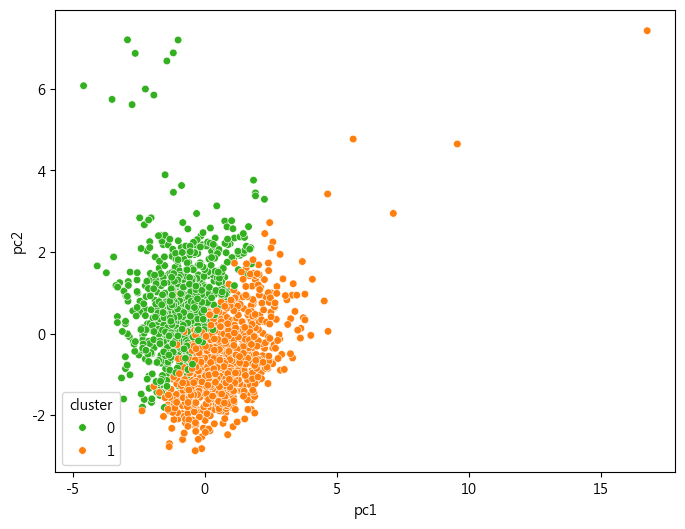

cluster sizes: {0: 713, 1: 812}
cluster    0    1
y                
0        667  763
1         46   49
cluster    0    1
y                
0        667  763
1         46   49


In [97]:
# ===== 0) 你的篩選結果：用 feature_idx 對回「原始欄位順序」取得 feature names =====
feature_idx = [234,  87,  33,  74,   6, 425,  93, 107, 446, 306, 388, 338, 108,
        148, 300, 120, 242,  30, 371,   5, 239,  34, 136,  25, 419, 456,
        275,  23, 265, 193,  12, 422,  13, 190, 262, 272, 156,  61,  83,
        133, 450, 377]

secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1'] > 10) | (X_pca_df['pc2'] > 10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')

# 原始特徵欄位（順序就是 feature_idx 的對應基準）
X_raw = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1: 0, 1: 1}).astype(int)

# 由 feature_idx 取出對應 feature names（以原始欄位順序為準）
raw_cols = X_raw.columns.to_list()
selected_features = [raw_cols[i] for i in feature_idx if 0 <= i < len(raw_cols)]

# 套回原始資料，只保留你要的特徵再走後續流程
X = X_raw.loc[:, selected_features].copy()


# ===== 1) 原本的清理流程照跑（但只對 selected_features） =====
na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()

uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()

X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

# 若因清理被刪掉一些欄位，保持輸出順序一致
selected_features_kept = [c for c in selected_features if c in X.columns]
X = X.loc[:, selected_features_kept].copy()
print("selected kept:", len(selected_features_kept), " / selected total:", len(selected_features))


# ===== 2) impute / scale / SMOTE / PCA / KMeans =====
imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_std)
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1] + 1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)
X_pca_df['cluster'] = cluster


# ===== 3) 你原本的可視化/統計照用 =====
plt.figure(figsize=(8, 6))
palette = {0: "#33B020", 1: "#ff7f0e"}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='cluster', s=30, palette=palette)
plt.show()

sizes = pd.Series(cluster).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': cluster})
ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

ct1 = pd.crosstab(df.iloc[:1525,]['y'], df.iloc[:1525,]['label'], rownames=['y'], colnames=['cluster'])
print(ct1)


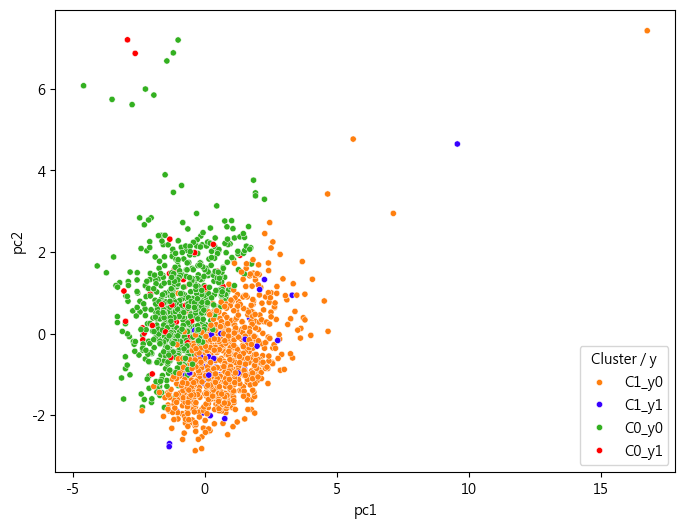

In [98]:
X_pca_df['y'] = y.values

# 建一個 4 類別欄位： (cluster, y)
X_pca_df['group'] = (
    'C' + X_pca_df['cluster'].astype(str) + '_y' + X_pca_df['y'].astype(str)
)
# 這樣會有：C0_y0, C0_y1, C1_y0, C1_y1 四種

plt.figure(figsize=(8,6))
# 自訂 4 種顏色（可自行調整）
palette = {
    'C0_y0': "#33B020",  # cluster 0, y=0
    'C0_y1': "#ff0000",  # cluster 0, y=1
    'C1_y0': '#ff7f0e',  # cluster 1, y=0
    'C1_y1': "#3700ff",  # cluster 1, y=1
}
sns.scatterplot(
    data=X_pca_df,
    x='pc1', y='pc2',
    hue='group',
    palette=palette,
    s=20
)
plt.legend(title='Cluster / y', loc='best')
plt.show()